<a href="https://colab.research.google.com/github/hwsinha/Brain-Tumor-Detector/blob/main/deep_learning_brain_tumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Import Libraries & Tools

In [2]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle


# Load Datasets

In [3]:
train_dir ='/content/drive/MyDrive/mri-data/Training/'
test_dir ='/content/drive/MyDrive/mri-data/Testing/'

#load and shuffle the train data
train_paths = []
train_labels =[]

for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir, label)):
    train_paths.append(os.path.join(train_dir, label, image))
    train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)


#load and shuffle the test data
test_paths = []
test_labels =[]

for label in os.listdir(test_dir):
  for image in os.listdir(os.path.join(test_dir, label)):
    test_paths.append(os.path.join(test_dir, label, image))
    test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)


# Data Visualization

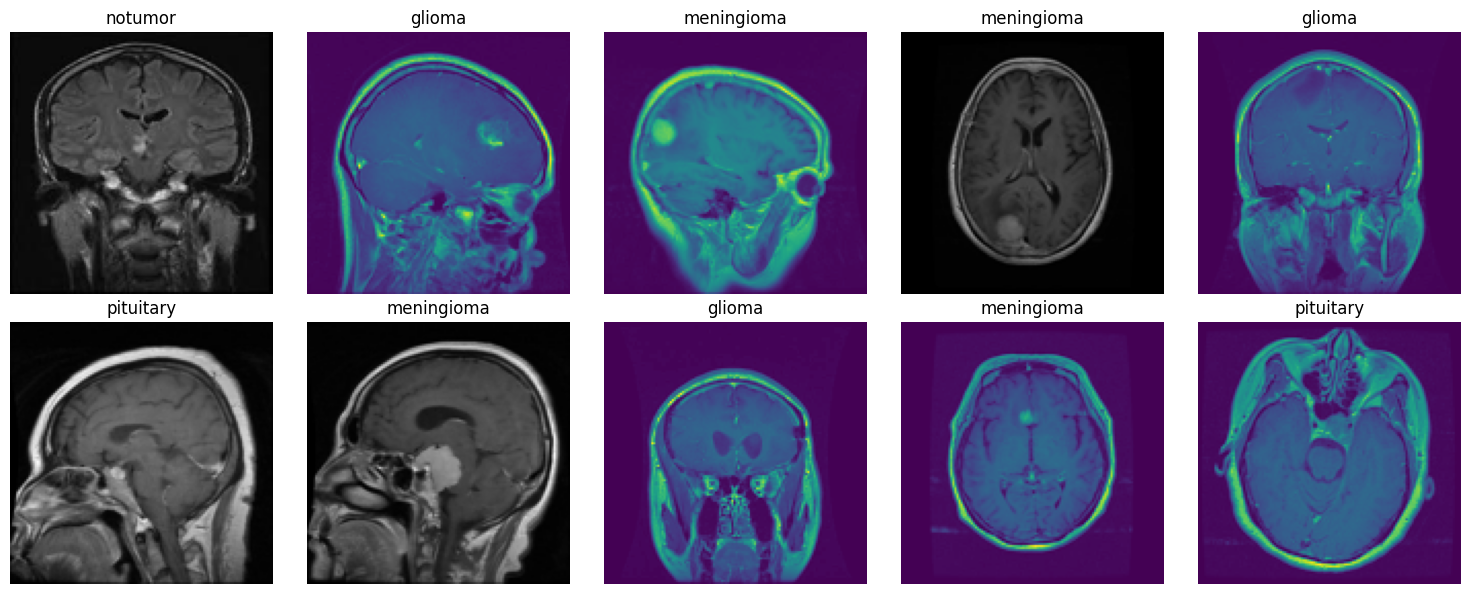

In [4]:
import matplotlib.pyplot as plt

#Select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)
random_indices

#create a fig to display img in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes =axes.ravel()

#Loop through the random indices and display img
for i, idx in enumerate(random_indices):
  img_path = train_paths[idx]
  img = Image.open(img_path)
  img = img.resize((128,128))

  #Display img
  axes[i].imshow(img)
  axes[i].axis('off')
  axes[i].set_title(train_labels[idx])

plt.tight_layout()
plt.show()


# Image Preprocessing (helper functions) (in progress)

In [5]:
#Image Augmentation Function
def Augment_image(image):
  image= Image.fromarray(np.uint8(image))


#Load images and apply augmentation
def open_images(paths):
  pass

#Encoder labels (Convert label names to integers)
def encode_label(labels):
  pass

#Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
  pass

# MODEL

**WE ARE GOING TO USE VGG16 FOR TRANSFER LEARNING**

In [ ]:
# Model Architecture
IMAGE_SIZE = 128
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), weights='imagenet', include_top=False)

# Freeze all layers of VGG16 base model
for layers in base_model.layers:
    layers.trainable = False

# Set only last few layers to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build Model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
model.add(base_model) # VGG16 base model
model.add(Flatten()) # Flatten layer cause base model layers were multi dimensional
model.add(Dropout(0.3)) # Dropout layer (drop randomly 30% neurons)
model.add(Dropout(0.3)) # Dropout layer

model.add(Dense(128, activation='relu')) # Dense layer
model.add(Dropout(0.2)) # Dropout layer

model.add(Dense(4, activation='softmax')) # Output layer

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)
epochs = 5

# Train model
history = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    steps_per_epoch=steps,
)